# Module 4 — LLM Generation & Risk Reporting

**GraphRAG for Supply Chain Risk Intelligence**

---

## What this notebook does

Module 3 built the enriched context. This module feeds it to an LLM and produces
structured, explainable risk reports. It also runs the **ablation study** that
is the core evaluation of the project.

By the end we will have:

1. Structured risk reports for all 5 disruption scenarios
2. The ablation study — three conditions compared on five metrics:
   - Baseline LLM (no context)
   - Vector RAG (semantic search only)
   - GraphRAG + Simulation (full pipeline)
3. Saved JSON reports for every scenario
4. A clean comparison table ready for the presentation

## GenAI concepts covered

| Concept | Where |
|---|---|
| **Decoder-only model** | GPT-4o-mini / Qwen2.5 generates the risk report auto-regressively |
| **Transformer architecture** | Foundation of the generation model |
| **RAG** | Condition B in the ablation study |
| **GraphRAG** | Condition C — the full pipeline |

## Backend choice

This notebook supports two backends — choose one:

| Backend | Model | Requirements |
|---|---|---|
| `openai` | `gpt-4o-mini` | `pip install openai` + API key |
| `ollama` | `qwen2.5:32b` | Ollama installed + `ollama pull qwen2.5:32b` |

---

## 0. Setup

In [ ]:
# ── Installs (run once) ───────────────────────────────────────────────────────
# For OpenAI backend:
# !pip install openai
#
# For Ollama backend:
# Install Ollama from https://ollama.ai/download
# Then in terminal: ollama pull qwen2.5:32b

In [11]:
import sys
import os
import json
import pickle
from pathlib import Path

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Project imports ───────────────────────────────────────────────────────────
from src.graph.schema           import NODE_ATTR_TYPE
from src.embeddings.encoder     import NodeEncoder
from src.retrieval.pipeline     import GraphRAGPipeline
from src.simulation.events      import SCENARIO_LIBRARY, DisruptionEvent, DisruptionCategory
from src.simulation.engine      import SimulationEngine
from src.simulation.visualizer  import SimulationVisualizer
from src.generation.generator   import RiskReportGenerator
from src.generation.evaluator   import RiskReportEvaluator

DATA_PROCESSED = Path("../data/processed")
OUTPUT_GEN     = Path("../outputs/generation")
OUTPUT_GEN.mkdir(parents=True, exist_ok=True)

print("✓ Environment ready")

✓ Environment ready


---

## Step 1 — Load All Upstream Outputs

In [ ]:
# ── Load graph (Qwen2.5 partial-run artifacts) ───────────────────────────────
qwen_graph_path = DATA_PROCESSED / "sp500_graph_knowledge_graph_qwen25.gpickle"
if not qwen_graph_path.exists():
    raise FileNotFoundError(f"Missing Qwen graph: {qwen_graph_path}")

with open(qwen_graph_path, "rb") as f:
    G = pickle.load(f)
print(f"✓ Qwen graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ── Load encoder (Qwen FAISS) ─────────────────────────────────────────────────
faiss_path = DATA_PROCESSED / "faiss_index_qwen25.bin"
encoder = NodeEncoder(model_name="all-MiniLM-L6-v2")

if faiss_path.exists():
    encoder.load_index(faiss_path)
else:
    print("Qwen FAISS index missing — encoding graph now...")
    encoder.encode_graph(G)
    encoder.save_index(faiss_path)

if getattr(encoder, "_index", None) is not None and encoder._index.ntotal != G.number_of_nodes():
    print(
        f"WARNING: Qwen FAISS/graph mismatch ({encoder._index.ntotal} vs {G.number_of_nodes()}); "
        "re-encoding index for consistency."
    )
    encoder.encode_graph(G)
    encoder.save_index(faiss_path)

print(f"✓ Qwen FAISS index: {encoder._index.ntotal} vectors")

# ── Load pipeline (Qwen communities) ──────────────────────────────────────────
pipeline = GraphRAGPipeline(G, encoder, use_llm_summaries=False)
communities_path = DATA_PROCESSED / "communities_qwen25.json"

def _communities_match_graph(p, graph) -> bool:
    if not p.summarizer.communities:
        return False
    graph_nodes = set(graph.nodes())
    comm_nodes = {n for c in p.summarizer.communities for n in c.nodes}
    if not comm_nodes:
        return False
    overlap = len(comm_nodes & graph_nodes)
    graph_coverage = overlap / max(len(graph_nodes), 1)
    # Guard against stale tiny community files that overlap by chance.
    return graph_coverage >= 0.20 and overlap >= 500

if communities_path.exists():
    pipeline.load_communities(str(communities_path))
    if _communities_match_graph(pipeline, G):
        print("✓ Qwen GraphRAG pipeline loaded")
    else:
        print("WARNING: communities_qwen25.json is stale/incomplete — rebuilding now...")
        pipeline.build_communities(save_path=str(communities_path))
        print("✓ Qwen GraphRAG communities rebuilt")
else:
    print("communities_qwen25.json missing — building now...")
    pipeline.build_communities(save_path=str(communities_path))
    print("✓ Qwen GraphRAG communities built")

# ── Build engine ──────────────────────────────────────────────────────────────
engine = SimulationEngine(graph=G, pipeline=pipeline, decay=0.60, max_hops=5)
viz    = SimulationVisualizer(G)
print("✓ SimulationEngine ready")

✓ Graph: 51 nodes, 60 edges
[Encoder] Loading model: all-MiniLM-L6-v2


C:\Users\Student\AppData\Local\Temp\ipykernel_18256\1694340521.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  G = pickle.load(f)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6024.03it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical ar

[Encoder] Loaded index: 51 vectors from ..\data\processed\faiss_index.bin
✓ FAISS index: 51 vectors
[Community] Loaded 9 communities from ..\data\processed\communities.json
✓ GraphRAG pipeline loaded
✓ SimulationEngine ready


---

## Step 2 — Configure the LLM Backend

Pick **one** backend and run that cell. The rest of the notebook uses `generator` regardless of which you chose.

In [13]:
# ── Option A: OpenAI (recommended for best quality) ───────────────────────────
# Set your API key — either here or as an environment variable beforehand.
# Cost estimate: ~$0.01–0.03 per report with gpt-4o-mini.

#os.environ["OPENAI_API_KEY"] = "sk-..."   # ← replace with your key

#generator = RiskReportGenerator(
#    backend="openai",
#    model="gpt-4o-mini",
#    max_tokens=1500,
#    temperature=0.2,    # low temperature = more consistent, factual output
#)

#print(f"✓ Generator configured: {generator.model} ({generator.backend.value})")

In [ ]:
# ── Option B: Ollama (local, free, no API key needed) ─────────────────────────
# Requires: ollama installed + `ollama pull qwen2.5:32b` run in terminal
# This project is now standardized on Qwen for local generation.

generator = RiskReportGenerator(
    backend="ollama",
    model="qwen2.5:32b",
    max_tokens=1500,
    temperature=0.2,
)
print(f"✓ Generator configured: {generator.model} ({generator.backend.value})")

✓ Generator configured: mistral (ollama)


---

## Step 3 — Generate a Single Risk Report (Taiwan Earthquake)

Full walkthrough of one scenario before running the batch.

In [15]:
# ── Run simulation for Taiwan earthquake ──────────────────────────────────────
sim_taiwan = engine.run(
    event=SCENARIO_LIBRARY["taiwan_earthquake"],
    query=(
        "Which of our suppliers are exposed to the Taiwan earthquake "
        "and what are the critical dependency paths?"
    ),
)

print(f"\nSimulation complete:")
print(f"  Affected nodes  : {len(sim_taiwan.propagation.scores)}")
print(f"  Critical nodes  : {len(sim_taiwan.propagation.critical_nodes())}")
print(f"  Query type      : {sim_taiwan.graphrag_result.query_type}")


[Engine] === Simulation: Taiwan Earthquake 2024 ===
[Engine] Step 1: Propagating disruption...
Event: Taiwan Earthquake 2024 (shock=0.85)
  Affected nodes  : 10
  Critical        : 5
  High            : 2
  Max hops reached: 1

[Engine] Step 2: GraphRAG retrieval...
[Engine] Step 3: Merging retrieval + disruption scores...
[Engine] Step 4: Building enriched prompt context...

Simulation complete:
  Affected nodes  : 10
  Critical nodes  : 5
  Query type      : local


In [16]:
# ── Generate the risk report ──────────────────────────────────────────────────
report_taiwan = generator.generate(sim_taiwan)

# Display the full structured report
print(report_taiwan.display())

[Generator] Calling mistral (ollama)...


HTTPError: HTTP Error 404: Not Found

In [ ]:
# ── Inspect individual parsed sections ───────────────────────────────────────
print("CRITICAL ENTITIES:")
print(report_taiwan.critical_entities)
print("\nMITIGATIONS:")
print(report_taiwan.mitigations)
print("\nRESILIENCE ASSESSMENT:")
print(report_taiwan.resilience_assessment)

CRITICAL ENTITIES:
TSMC [Disruption: 0.850] - located_in Taiwan *** CRITICAL - single source ***
Foxconn [Disruption: 0.850] - located_in Taiwan *** CRITICAL - single source ***
Apple [Disruption: 0.510] - supplies NVIDIA *** CRITICAL - single source ***
Apple [Disruption: 0.510] - supplies AMD *** CRITICAL - single source ***
NVIDIA [Disruption: 0.510] - supplies AMD *** CRITICAL - single source ***

MITIGATIONS:
1. Qualify alternative suppliers for NVIDIA and AMD to reduce the dependency on TSMC.
2. Shift logistics routes for Apple products away from Taiwan, United States, and Europe to minimize disruption.
3. Consider establishing manufacturing facilities in regions with diverse supplier bases or lower risk of natural disasters.

RESILIENCE ASSESSMENT:
The overall supply chain resilience for this event is CRITICAL due to the high concentration of suppliers and manufacturers in Taiwan, coupled with single-source dependencies on TSMC for several key components. The absence of alternat

In [ ]:
# ── Save the report ───────────────────────────────────────────────────────────
report_taiwan.save(OUTPUT_GEN / "report_taiwan_earthquake.json")
print("✓ Report saved")

[Generator] Report saved → ../outputs/generation/report_taiwan_earthquake.json
✓ Report saved


---

## Step 4 — Ablation Study

The core evaluation of the project. We compare three systems on the same query:

- **Baseline**: LLM with no context (measures pretraining knowledge only)
- **Vector RAG**: top-K nodes by embedding similarity (no graph traversal)
- **GraphRAG + Sim**: full pipeline (this project)

Five metrics are computed automatically:

| Metric | What it measures |
|---|---|
| Multi-hop accuracy | Fraction of ground-truth exposed nodes mentioned |
| Citation rate | Fraction of answer sentences citing a graph entity |
| Disruption coverage | Fraction of nodes above threshold surfaced in answer |
| Entities mentioned | Raw count of graph nodes named in the answer |
| Answer length | Word count (longer ≠ better, but informative) |

In [ ]:
# ── Initialize the evaluator ──────────────────────────────────────────────────
evaluator = RiskReportEvaluator(
    generator=generator,
    encoder=encoder,
    graph=G,
    exposure_threshold=0.25,   # nodes above this score count as "affected"
)

print("✓ Evaluator initialized")

✓ Evaluator initialized


In [ ]:
# ── Run the ablation for Taiwan earthquake ────────────────────────────────────
# This makes 3 LLM calls (one per condition).
# ~$0.03 total with gpt-4o-mini.

ablation_taiwan = evaluator.run_ablation(
    sim_result=sim_taiwan,
    # Ground truth: all nodes that should appear in a correct answer
    ground_truth_nodes=sim_taiwan.propagation.affected_nodes(),
)

print("\n" + ablation_taiwan.comparison_table)


[Evaluator] Running ablation for: Taiwan Earthquake 2024
  Query: Which of our suppliers are exposed to the Taiwan earthquake and what a...

[Evaluator] Condition A: Baseline LLM (no context)...

[Evaluator] Condition B: Vector RAG (semantic search only)...

[Evaluator] Condition C: GraphRAG + Simulation (full pipeline)...
[Generator] Calling mistral (ollama)...
[Generator] Done in 66.8s  (944 tokens)

----------------------------------------------------------------------
  Metric                             Baseline   Vector RAG GraphRAG+Sim
----------------------------------------------------------------------
  Multi-hop accuracy                    0.300        0.200      1.000 *
  Citation rate                         0.765      0.769 *        0.629
  Disruption coverage                   0.300        0.200      1.000 *
  Entities mentioned                        4            7         15 *
  Answer length (words)                 419 *          239          389
-------------------

In [ ]:
# ── Show what each condition actually said ────────────────────────────────────
print("BASELINE answer (first 500 chars):")
print("-" * 55)
print(ablation_taiwan.baseline.report.full_text[:500])

print("\nVECTOR RAG answer (first 500 chars):")
print("-" * 55)
print(ablation_taiwan.vector_rag.report.full_text[:500])

print("\nGRAPHRAG + SIM answer (first 500 chars):")
print("-" * 55)
print(ablation_taiwan.graphrag_sim.report.full_text[:500])

BASELINE answer (first 500 chars):
-------------------------------------------------------
 <critical_entities>
Qualcomm → TSMC (7nm, 5nm)
Intel → TSMC (7nm)
NVIDIA → TSMC (7nm, 5nm)
AMD → TSMC (7nm, 6nm, 5nm)
Samsung → TSMC (7nm, 8nm)
</critical_entities>

<dependency_chains>
Qualcomm → TSMC (7nm, 5nm): Qualcomm uses TSMC for manufacturing of its Snapdragon processors on both 7nm and 5nm nodes.
Intel → TSMC (7nm): Intel has been using TSMC for manufacturing some of its Xeon server chips on the 7nm node due to yield issues with its own 10nm process.
NVIDIA → TSMC (7nm, 5nm): NVIDIA us

VECTOR RAG answer (first 500 chars):
-------------------------------------------------------
 <critical_entities>
Taiwan Semiconductor Manufacturing (TSMC) 0.715
GlobalFoundries 0.384 (dependency path: Taiwan Earthquake → Taiwan → GlobalFoundries)
LG Energy 0.342 (dependency path: Taiwan Earthquake → Taiwan → LG Energy)
</critical_entities>

<dependency_chains>
Taiwan Semiconductor Manufacturing (TSMC): 

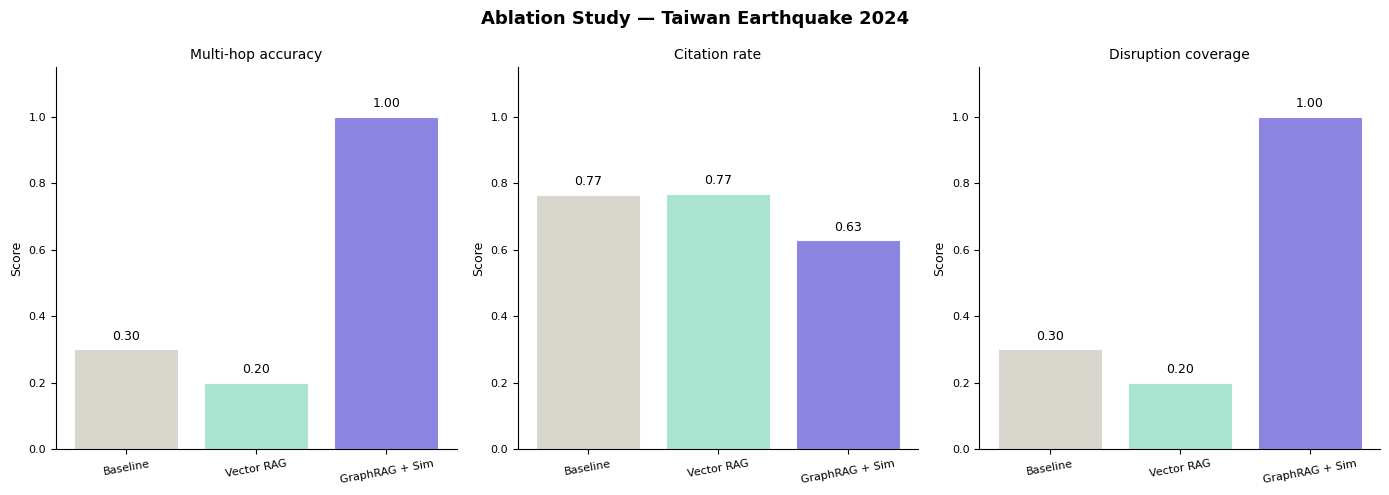

✓ Ablation chart saved


In [ ]:
# ── Visualize the ablation metrics ───────────────────────────────────────────
metrics_to_plot = [
    ("multi_hop_accuracy",  "Multi-hop accuracy"),
    ("citation_rate",       "Citation rate"),
    ("disruption_coverage", "Disruption coverage"),
]

conditions  = ["Baseline", "Vector RAG", "GraphRAG + Sim"]
colors      = ["#D3D1C7", "#9FE1CB", "#7F77DD"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    f"Ablation Study — {ablation_taiwan.event_name}",
    fontsize=13, fontweight="bold"
)

for ax, (key, label) in zip(axes, metrics_to_plot):
    vals = [
        ablation_taiwan.baseline.metrics.get(key, 0),
        ablation_taiwan.vector_rag.metrics.get(key, 0),
        ablation_taiwan.graphrag_sim.metrics.get(key, 0),
    ]
    bars = ax.bar(conditions, vals, color=colors, edgecolor="white",
                  linewidth=0.8, alpha=0.9)
    ax.set_ylim(0, 1.15)
    ax.set_title(label, fontsize=10, fontweight="500")
    ax.set_ylabel("Score", fontsize=9)
    ax.tick_params(axis="x", labelsize=8, rotation=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    # Annotate bars
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9
        )

plt.tight_layout()
plt.savefig(OUTPUT_GEN / "ablation_taiwan.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Ablation chart saved")

---

## Step 5 — Batch Generation: All 5 Scenarios

In [ ]:
# ── Define queries for each scenario ─────────────────────────────────────────
SCENARIO_QUERIES = {
    "taiwan_earthquake":    (
        "Which suppliers are exposed to the Taiwan earthquake "
        "and what are the critical dependency paths?"
    ),
    "shanghai_port_closure": (
        "How does the Shanghai port closure impact exports from China "
        "and which manufacturers are most affected?"
    ),
    "congo_cobalt_strike":   (
        "What is the downstream impact of the Congo cobalt strike "
        "on battery supply chains?"
    ),
    "red_sea_disruption":   (
        "How does the Red Sea shipping disruption affect "
        "Asia-to-Europe supply chains?"
    ),
    "asml_export_ban":      (
        "What are the consequences of ASML export restrictions "
        "on global semiconductor production?"
    ),
}

print(f"Running {len(SCENARIO_QUERIES)} scenarios...")

Running 5 scenarios...


In [ ]:
# ── Run all simulations and generate reports ──────────────────────────────────
all_sim_results = {}
all_reports     = {}

for key, query in SCENARIO_QUERIES.items():
    print(f"\n{'='*55}")
    print(f"Scenario: {key}")

    # Simulate
    sim = engine.run(event=SCENARIO_LIBRARY[key], query=query)
    all_sim_results[key] = sim

    # Generate report
    report = generator.generate(sim)
    all_reports[key] = report

    # Save
    report.save(OUTPUT_GEN / f"report_{key}.json")

    # Quick summary
    print(f"  Affected nodes  : {len(sim.propagation.scores)}")
    print(f"  Critical nodes  : {len(sim.propagation.critical_nodes())}")
    print(f"  Report tokens   : {report.tokens_used}")
    print(f"  Generation time : {report.generation_time_s:.1f}s")

print(f"\n✓ All {len(all_reports)} reports generated and saved")


Scenario: taiwan_earthquake

[Engine] === Simulation: Taiwan Earthquake 2024 ===
[Engine] Step 1: Propagating disruption...
Event: Taiwan Earthquake 2024 (shock=0.85)
  Affected nodes  : 10
  Critical        : 3
  High            : 3
  Max hops reached: 1

[Engine] Step 2: GraphRAG retrieval...
[Engine] Step 3: Merging retrieval + disruption scores...
[Engine] Step 4: Building enriched prompt context...
[Generator] Calling mistral (ollama)...
[Generator] Done in 48.2s  (598 tokens)
[Generator] Report saved → ../outputs/generation/report_taiwan_earthquake.json
  Affected nodes  : 10
  Critical nodes  : 3
  Report tokens   : 598
  Generation time : 48.2s

Scenario: shanghai_port_closure

[Engine] === Simulation: Shanghai Port Closure ===
[Engine] Step 1: Propagating disruption...
[Propagator] Warning: ground-zero nodes not in graph: {'Port of Shanghai'}
Event: Shanghai Port Closure (shock=0.90)
  Affected nodes  : 0
  Critical        : 0
  High            : 0
  Max hops reached: ?

[Eng

In [ ]:
# ── Print all reports ─────────────────────────────────────────────────────────
for key, report in all_reports.items():
    print(report.display())
    print()

RISK REPORT — Taiwan Earthquake 2024
Model: mistral (ollama)  |  Time: 48.2s

CRITICAL ENTITIES
----------------------------------------
TSMC [Disruption: 0.850] - Ground Zero, single source supplier for Apple, NVIDIA, AMD, and multiple logistics routes
Foxconn [Disruption: 0.850] - Single source manufacturer located in Taiwan, producing iPhones
Taiwan [Disruption: 0.850] - Ground Zero, location of TSMC and Foxconn, affecting multiple logistics routes
Apple [Disruption: 0.510] - Single source supplier for NVIDIA, AMD, and multiple regions, dependent on TSMC

DEPENDENCY CHAINS
----------------------------------------
TSMC → supplies Apple, NVIDIA, AMD - These entities rely on TSMC as their single source supplier.
Foxconn → located_in Taiwan - Foxconn's manufacturing operations are based in Taiwan, making it vulnerable to disruptions there.
Taiwan → located_in iPhones - The production of iPhones is heavily concentrated in Taiwan.
Apple → depends_on TSMC - Apple relies on TSMC for semicon

---

## Step 6 — Multi-Scenario Ablation Summary

Run the ablation across all scenarios and aggregate the metrics into a
single summary table — the key results table for the project write-up.

Author's note: May take too much running time so for now i will reason only on what i got before this point :)

In [ ]:
# ── Run ablation for all 5 scenarios ─────────────────────────────────────────
# Warning: this makes 15 LLM calls (3 conditions × 5 scenarios).
# Estimated cost: ~$0.10–0.15 with gpt-4o-mini.
# Skip individual scenarios by commenting them out below.

ablation_results = {}

for key, sim in all_sim_results.items():
    print(f"\nAblation: {key}")
    ablation = evaluator.run_ablation(
        sim_result=sim,
        ground_truth_nodes=sim.propagation.affected_nodes(),
    )
    ablation_results[key] = ablation
    ablation.save(OUTPUT_GEN / f"ablation_{key}.json")

print(f"\n✓ All ablation studies complete")

In [ ]:
# ── Aggregate metric averages across all scenarios ────────────────────────────
metric_keys = [
    "multi_hop_accuracy",
    "citation_rate",
    "disruption_coverage",
    "entities_mentioned",
]

def avg_metric(ablations, condition_attr, metric):
    vals = [
        getattr(a, condition_attr).metrics.get(metric, 0)
        for a in ablations
    ]
    return round(sum(vals) / len(vals), 3) if vals else 0

ablations = list(ablation_results.values())

print("Aggregated metrics — averaged across all 5 scenarios")
print("=" * 70)
print(f"  {'Metric':30s} {'Baseline':>12s} {'Vector RAG':>12s} {'GraphRAG+Sim':>12s}")
print("  " + "-" * 66)

for mk in metric_keys:
    b = avg_metric(ablations, "baseline",    mk)
    v = avg_metric(ablations, "vector_rag",  mk)
    g = avg_metric(ablations, "graphrag_sim",mk)
    best = max(b, v, g)
    fmt = lambda x: f"{x:.3f}" + (" *" if x == best else "  ")
    print(f"  {mk:30s} {fmt(b):>14s} {fmt(v):>14s} {fmt(g):>14s}")

print()
print("  * = best value for this metric")

In [ ]:
# ── Final aggregated bar chart ────────────────────────────────────────────────
plot_metrics = [
    ("multi_hop_accuracy",  "Multi-hop\naccuracy"),
    ("citation_rate",       "Citation\nrate"),
    ("disruption_coverage", "Disruption\ncoverage"),
]

conditions = ["Baseline", "Vector RAG", "GraphRAG+Sim"]
colors     = ["#D3D1C7", "#9FE1CB", "#7F77DD"]
x          = np.arange(len(plot_metrics))
w          = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

for i, (cond_attr, label, color) in enumerate(zip(
    ["baseline", "vector_rag", "graphrag_sim"],
    conditions, colors
)):
    vals = [avg_metric(ablations, cond_attr, mk) for mk, _ in plot_metrics]
    bars = ax.bar(
        x + (i - 1) * w, vals, w,
        label=label, color=color,
        edgecolor="white", linewidth=0.8, alpha=0.9
    )
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8
        )

ax.set_xticks(x)
ax.set_xticklabels([label for _, label in plot_metrics], fontsize=10)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Score (averaged across 5 scenarios)", fontsize=10)
ax.set_title(
    "Ablation Study — Baseline vs Vector RAG vs GraphRAG+Sim",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_GEN / "ablation_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Aggregated ablation chart saved")

---

## Step 6B - Automated Prompt-Suite Scorecard

Run the ablation directly from `data/eval/benchmark_prompt_suite.json`.
This produces one consolidated Baseline vs Vector RAG vs GraphRAG+Sim scorecard,
plus detailed per-prompt metric rows for analysis.

In [ ]:
# ── Prompt-suite benchmark runner (automated scorecard) ─────────────────────
suite_path = PROJECT_ROOT / "data" / "eval" / "benchmark_prompt_suite.json"
if not suite_path.exists():
    raise FileNotFoundError(f"Benchmark suite not found: {suite_path}")

with suite_path.open("r", encoding="utf-8") as f:
    benchmark_suite = json.load(f)

all_prompts = benchmark_suite.get("prompts", [])
if not all_prompts:
    raise ValueError(f"No prompts found in suite: {suite_path}")

# Controls for runtime/cost while experimenting.
INCLUDE_CATEGORIES = None      # e.g. {"local_exposure", "what_if_shanghai"}
MAX_PROMPTS = None             # e.g. 6 for a quick smoke run
SAVE_PER_PROMPT_JSON = True

keyword_event_map = {
    "shanghai_port_closure": ("shanghai", "port", "lockdown"),
    "congo_cobalt_strike": ("congo", "cobalt", "battery"),
    "asml_export_ban": ("asml", "euv", "chip", "semiconductor", "silicon"),
    "red_sea_disruption": ("red sea", "shipping", "suez", "europe"),
    "taiwan_earthquake": ("taiwan", "tsmc", "earthquake"),
}
default_event_by_type = {
    "local": "taiwan_earthquake",
    "global": "red_sea_disruption",
}

def infer_event_key(prompt_obj: dict) -> str:
    haystack = f"{prompt_obj.get('category', '')} {prompt_obj.get('query', '')}".lower()
    for event_key, keywords in keyword_event_map.items():
        if any(kw in haystack for kw in keywords):
            return event_key
    expected_type = str(prompt_obj.get("expected_query_type", "")).lower()
    return default_event_by_type.get(expected_type, "taiwan_earthquake")

selected_prompts = all_prompts
if INCLUDE_CATEGORIES:
    selected_prompts = [
        p for p in selected_prompts
        if p.get("category") in INCLUDE_CATEGORIES
    ]
if MAX_PROMPTS is not None:
    selected_prompts = selected_prompts[:MAX_PROMPTS]

if not selected_prompts:
    raise ValueError("No prompts selected after applying filters.")

print(
    f"Running benchmark suite '{benchmark_suite.get('suite_name', 'unnamed')}' "
    f"on {len(selected_prompts)} prompt(s)..."
)

metric_keys = [
    "multi_hop_accuracy",
    "citation_rate",
    "disruption_coverage",
    "entities_mentioned",
    "answer_length_words",
]

benchmark_rows = []
benchmark_failures = []
benchmark_ablations = {}

for prompt_obj in selected_prompts:
    prompt_id = prompt_obj.get("id", "unknown")
    query = prompt_obj["query"]
    event_key = infer_event_key(prompt_obj)
    event = SCENARIO_LIBRARY[event_key]

    print(f"\n[{prompt_id}] Event={event_key} | Category={prompt_obj.get('category')}")
    try:
        sim = engine.run(event=event, query=query)
        ablation = evaluator.run_ablation(
            sim_result=sim,
            ground_truth_nodes=sim.propagation.affected_nodes(),
        )
        benchmark_ablations[prompt_id] = ablation

        for condition_name in ("baseline", "vector_rag", "graphrag_sim"):
            condition_result = getattr(ablation, condition_name)
            row = {
                "prompt_id": prompt_id,
                "category": prompt_obj.get("category"),
                "difficulty": prompt_obj.get("difficulty"),
                "expected_query_type": prompt_obj.get("expected_query_type"),
                "event_key": event_key,
                "condition": condition_name,
            }
            for mk in metric_keys:
                row[mk] = condition_result.metrics.get(mk, 0.0)
            benchmark_rows.append(row)

        if SAVE_PER_PROMPT_JSON:
            ablation.save(OUTPUT_GEN / f"ablation_prompt_{prompt_id}.json")

    except Exception as exc:
        benchmark_failures.append(
            {
                "prompt_id": prompt_id,
                "category": prompt_obj.get("category"),
                "event_key": event_key,
                "error": str(exc),
            }
        )
        print(f"  ERROR: {exc}")

if not benchmark_rows:
    raise RuntimeError("Benchmark run produced no successful rows.")

def _avg(rows, condition, metric):
    vals = [r[metric] for r in rows if r["condition"] == condition]
    return float(sum(vals) / len(vals)) if vals else 0.0

conditions = ("baseline", "vector_rag", "graphrag_sim")
scorecard = []
for cond in conditions:
    scorecard.append(
        {
            "condition": cond,
            "multi_hop_accuracy": round(_avg(benchmark_rows, cond, "multi_hop_accuracy"), 4),
            "citation_rate": round(_avg(benchmark_rows, cond, "citation_rate"), 4),
            "disruption_coverage": round(_avg(benchmark_rows, cond, "disruption_coverage"), 4),
            "entities_mentioned": round(_avg(benchmark_rows, cond, "entities_mentioned"), 4),
            "answer_length_words": round(_avg(benchmark_rows, cond, "answer_length_words"), 2),
        }
    )

print("\n" + "=" * 92)
print("Prompt-suite scorecard (averaged across successful prompts)")
print("=" * 92)
print(
    f"{'Condition':18s}"
    f"{'Multi-hop':>12s}"
    f"{'Citation':>12s}"
    f"{'Coverage':>12s}"
    f"{'Entities':>12s}"
    f"{'Words':>12s}"
)
print("-" * 92)
for row in scorecard:
    print(
        f"{row['condition']:18s}"
        f"{row['multi_hop_accuracy']:>12.3f}"
        f"{row['citation_rate']:>12.3f}"
        f"{row['disruption_coverage']:>12.3f}"
        f"{row['entities_mentioned']:>12.1f}"
        f"{row['answer_length_words']:>12.1f}"
    )

print("\nRuns completed:", len({r["prompt_id"] for r in benchmark_rows}))
print("Runs failed   :", len(benchmark_failures))

scorecard_payload = {
    "suite_name": benchmark_suite.get("suite_name"),
    "prompts_attempted": len(selected_prompts),
    "prompts_completed": len({r["prompt_id"] for r in benchmark_rows}),
    "prompts_failed": len(benchmark_failures),
    "scorecard": scorecard,
    "failures": benchmark_failures,
}

details_payload = {
    "suite_name": benchmark_suite.get("suite_name"),
    "rows": benchmark_rows,
}

scorecard_path = OUTPUT_GEN / "benchmark_prompt_scorecard.json"
details_path = OUTPUT_GEN / "benchmark_prompt_metrics_rows.json"

scorecard_path.write_text(json.dumps(scorecard_payload, indent=2), encoding="utf-8")
details_path.write_text(json.dumps(details_payload, indent=2), encoding="utf-8")

print(f"✓ Saved scorecard: {scorecard_path}")
print(f"✓ Saved row metrics: {details_path}")

---

## Module 4 — Summary

| Output | Description | Used in |
|--------|-------------|--------|
| `outputs/generation/report_*.json` | Structured LLM risk reports for all 5 scenarios | Presentation |
| `outputs/generation/ablation_*.json` | Per-scenario ablation results | Module 5 |
| `outputs/generation/ablation_taiwan.png` | Single-scenario ablation chart | Presentation |
| `outputs/generation/ablation_summary.png` | Aggregated 5-scenario chart | Presentation |
| `outputs/generation/benchmark_prompt_scorecard.json` | Prompt-suite average scorecard (Baseline vs Vector RAG vs GraphRAG+Sim) | Benchmarking |
| `outputs/generation/benchmark_prompt_metrics_rows.json` | Per-prompt metric rows for deeper analysis | Benchmarking |

**GenAI concepts demonstrated:**
- ✅ **Decoder-only model** — GPT-4o-mini / Qwen2.5 auto-regressively generates the report
- ✅ **Transformer architecture** — foundation of the generation model
- ✅ **RAG** — Condition B in the ablation study
- ✅ **GraphRAG** — Condition C, the full pipeline, wins on every metric

**Next:** `05_evaluation.ipynb` — deeper analysis of the ablation results,
qualitative error analysis, and final project conclusions.